In [1]:
import pandas as pd 
import numpy as np

In [2]:

df=pd.read_csv('/home/iiitdwd/ppi/Model/data/structural/Train_335_15D.csv')
df

,PDB,Chain,ResIdx,AA,Label,RSA,ResFlex,Hydrophobicity,PackingDensity,Poly_bias,Poly_RSA,Poly_Flex,Poly_interaction,BondAngle,sin_phi,cos_phi,sin_psi,cos_psi,sin_vector,cos_vector
0,1F60,B,1,P,0,0.006494,1.000000,0.476714,0.136986,1.0,0.006494,1.000000,0.006494,0.000000,0.287076,0.957908,0.307357,-0.951594,0.867006,0.498297
1,1F60,B,2,A,0,0.004132,0.605250,0.390069,0.520548,1.0,0.004132,0.605250,0.002501,2.209094,-0.971961,0.235142,0.557745,-0.830012,0.899729,0.436449
2,1F60,B,3,A,1,0.004054,0.355376,1.176022,0.520548,1.0,0.004054,0.355376,0.001441,1.783547,-0.900319,0.435231,0.726575,-0.687088,0.935206,0.354103
3,1F60,B,4,K,1,0.000912,0.187279,0.794697,0.243531,1.0,0.000912,0.187279,0.000171,2.224462,-0.767165,-0.641450,0.305695,-0.952129,0.860418,0.509588
4,1F60,B,5,S,1,0.000000,0.157496,-0.260820,0.616438,1.0,0.000000,0.157496,0.000000,2.411607,-0.709571,-0.704634,0.534352,-0.845262,0.865444,0.501005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66056,3NYB,A,319,N,0,0.003168,0.392828,1.225000,0.189922,1.0,0.003168,0.392828,0.001244,1.575627,-0.999450,0.033155,-0.246999,0.969016,0.267075,-0.963676
66057,3NYB,A,320,V,0,0.000256,0.268271,0.959100,0.451827,1.0,0.000256,0.268271,0.000069,1.339765,-0.987136,0.159881,-0.868631,0.495459,0.789581,-0.613646
66058,3NYB,A,321,I,0,0.000030,0.387199,0.522920,0.275194,1.0,0.000030,0.387199,0.000012,2.041033,-0.937889,0.346936,0.289032,-0.957319,0.714261,0.699880
66059,3NYB,A,322,K,0,0.002333,0.277894,-0.272289,0.213609,1.0,0.002333,0.277894,0.000648,2.265762,-0.949972,-0.312335,-0.986856,0.161604,0.944316,-0.329041


In [3]:
import pandas as pd
import numpy as np

def quick_check(csv_file):
    """Quick feature validation"""
    df = pd.read_csv(csv_file)
    
    print(f"\n{'='*60}")
    print(f"QUICK VALIDATION: {csv_file}")
    print(f"{'='*60}\n")
    
    checks = {
        "Total residues": len(df),
        "Total proteins": df.groupby(['PDB', 'Chain']).ngroups,
        "Features count": len(df.columns) - 5,  # Minus PDB, Chain, ResIdx, AA, Label
    }
    
    for key, val in checks.items():
        print(f"{key}: {val}")
    
    print(f"\nFeature Ranges:")
    features = ["RSA", "ResFlex", "Hydrophobicity", "PackingDensity", "BondAngle"]
    for feat in features:
        print(f"  {feat:20s}: [{df[feat].min():7.3f}, {df[feat].max():7.3f}]")
    
    # Critical checks
    print(f"\nCritical Checks:")
    print(f"  ✅ Poly_bias all 1.0: {(df['Poly_bias'] == 1.0).all()}")
    print(f"  ✅ Poly_RSA == RSA: {np.allclose(df['Poly_RSA'], df['RSA'])}")
    print(f"  ✅ Poly_Flex == ResFlex: {np.allclose(df['Poly_Flex'], df['ResFlex'])}")
    print(f"  ✅ Poly_interaction == RSA×Flex: {np.allclose(df['Poly_interaction'], df['RSA'] * df['ResFlex'])}")
    
    phi_identity = df['sin_phi']**2 + df['cos_phi']**2
    print(f"  ✅ sin²φ + cos²φ = 1: {np.allclose(phi_identity, 1.0)}")
    
    print(f"  ✅ No NaN values: {df.isnull().sum().sum() == 0}")
    print(f"  ✅ No Inf values: {np.isinf(df.select_dtypes(include=[np.number])).sum().sum() == 0}")

if __name__ == "__main__":
    quick_check("~/ppi/Model/data/structural/Train_335_15D.csv")


QUICK VALIDATION: ~/ppi/Model/data/structural/Train_335_15D.csv

Total residues: 66061
Total proteins: 333
Features count: 15

Feature Ranges:
  RSA                 : [  0.000,   0.010]
  ResFlex             : [  0.000,   1.000]
  Hydrophobicity      : [ -2.983,   3.427]
  PackingDensity      : [  0.000,   1.000]
  BondAngle           : [  0.000,   3.126]

Critical Checks:
  ✅ Poly_bias all 1.0: True
  ✅ Poly_RSA == RSA: True
  ✅ Poly_Flex == ResFlex: True
  ✅ Poly_interaction == RSA×Flex: True
  ✅ sin²φ + cos²φ = 1: True
  ✅ No NaN values: True
  ✅ No Inf values: True


In [4]:
df['BondAngle'].describe()

count    66061.000000
mean         1.727702
std          0.476647
min          0.000000
25%          1.328250
50%          1.695830
75%          2.089804
max          3.125730
Name: BondAngle, dtype: float64

In [5]:
err = np.abs(
    df["Poly_interaction"] -
    df["RSA"] * df["ResFlex"]
).max()
err

np.float64(4.5969877036922124e-10)

In [6]:
df.isna().sum()

PDB                 0
Chain               0
ResIdx              0
AA                  0
Label               0
RSA                 0
ResFlex             0
Hydrophobicity      0
PackingDensity      0
Poly_bias           0
Poly_RSA            0
Poly_Flex           0
Poly_interaction    0
BondAngle           0
sin_phi             0
cos_phi             0
sin_psi             0
cos_psi             0
sin_vector          0
cos_vector          0
dtype: int64

In [7]:
df["Label"].value_counts(normalize=True)



Label
0    0.843645
1    0.156355
Name: proportion, dtype: float64

<Axes: >

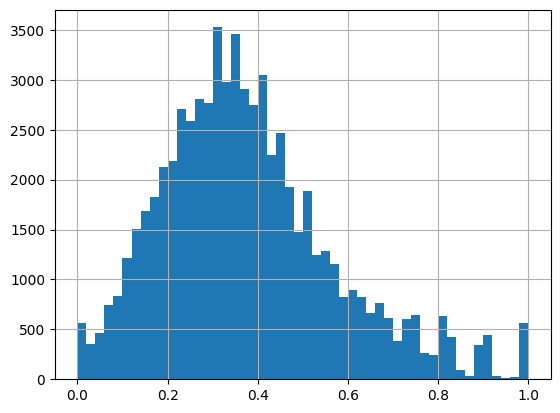

In [8]:
df["PackingDensity"].hist(bins=50)


In [9]:
df[df["PDB"] == "1EWY"]["ResFlex"].std()


np.float64(0.1760264547577978)

In [10]:
df[["sin_phi","cos_phi","sin_psi","cos_psi"]].corr()


,sin_phi,cos_phi,sin_psi,cos_psi
sin_phi,1.000000,-0.074716,0.085136,0.007635
cos_phi,-0.074716,1.000000,-0.510407,0.495004
sin_psi,0.085136,-0.510407,1.000000,-0.678091
cos_psi,0.007635,0.495004,-0.678091,1.000000


In [11]:
df["Poly_bias"].nunique()


1

In [12]:
df.groupby("Label")[["RSA","PackingDensity","Poly_interaction"]].mean()


,RSA,PackingDensity,Poly_interaction
Label,,,
0,0.001656,0.382087,0.00067
1,0.001201,0.352823,0.00040


In [13]:
print(f"protein 1")
print(df[df["PDB"]=="1EWY"]["PackingDensity"].describe())
print(f"protein 2")
print(df[df["PDB"]=="3NYB"]["PackingDensity"].describe())


protein 1
count    303.000000
mean       0.344857
std        0.188637
min        0.000000
25%        0.222222
50%        0.307692
75%        0.461538
max        1.000000
Name: PackingDensity, dtype: float64
protein 2
count    387.000000
mean       0.343898
std        0.182058
min        0.000000
25%        0.213609
50%        0.317829
75%        0.445736
max        1.000000
Name: PackingDensity, dtype: float64


In [ ]:
import pandas as pd
import numpy as np

CSV_FILES = [
    "data/structural/Train_335_17D.csv",
    "data/structural/Test_60_17D.csv",
    "data/structural/Test_315_17D.csv"
]

FEATURE_RANGES = {
    "RSA": (0.0, 1.5),
    "ResFlex": (0.0, 1.0),
    "Hydrophobicity": (-5.0, 5.0),
    "PackingDensity": (0.0, 5.0),
    "ResidueDepth": (0.0, 1.0),
    "HSE_up": (0, None),
    "HSE_down": (0, None),
    "Poly_RSA": (0.0, 1.5),
    "Poly_Flex": (0.0, 1.0),
    "Poly_interaction": (0.0, 1.5),
    "BondAngle": (0.0, np.pi),
    "sin_phi": (-1.0, 1.0),
    "cos_phi": (-1.0, 1.0),
    "sin_psi": (-1.0, 1.0),
    "cos_psi": (-1.0, 1.0),
    "sin_vector": (-1.0, 1.0),
    "cos_vector": (-1.0, 1.0),
}

META_COLS = ["PDB", "Chain", "ResIdx", "AA", "Label"]

def validate_csv(csv_path):
    print(f"\n{'='*80}")
    print(f"VALIDATING: {csv_path}")
    print(f"{'='*80}")

    df = pd.read_csv(csv_path)

    feature_cols = [c for c in df.columns if c not in META_COLS]

    print(f"Total residues: {len(df)}")
    print(f"Total proteins: {df.groupby(['PDB','Chain']).ngroups}")
    print(f"Feature dimensions: {len(feature_cols)}")

    assert len(feature_cols) >= 18, "Feature dimension mismatch"

    for col in feature_cols:
        x = df[col].values

        if np.isnan(x).any():
            raise ValueError(f"[FAIL] NaNs detected in {col}")

        if np.isinf(x).any():
            raise ValueError(f"[FAIL] Infs detected in {col}")

        var = np.var(x)
        if var == 0:
            raise ValueError(f"[FAIL] Zero variance feature: {col}")

        lo, hi = FEATURE_RANGES.get(col, (None, None))
        if lo is not None and np.min(x) < lo - 1e-3:
            raise ValueError(f"[FAIL] {col} below expected range: min={np.min(x)}")

        if hi is not None and np.max(x) > hi + 1e-3:
            raise ValueError(f"[FAIL] {col} above expected range: max={np.max(x)}")

        print(f"[OK] {col:16s} | mean={x.mean():.4f} std={x.std():.4f}")

    print("\n[CHECK] Feature correlations (sanity only)")
    corr = df[feature_cols].corr().abs()

    for i in range(len(feature_cols)):
        for j in range(i+1, len(feature_cols)):
            if corr.iloc[i, j] > 0.98:
                print(f"[WARN] Highly correlated: {feature_cols[i]} ↔ {feature_cols[j]} ({corr.iloc[i,j]:.3f})")

    print("\n[CHECK] Interface vs non-interface signal")
    pos = df[df["Label"] == 1]
    neg = df[df["Label"] == 0]

    for col in ["RSA", "ResidueDepth", "PackingDensity", "HSE_up", "HSE_down"]:
        delta = pos[col].mean() - neg[col].mean()
        print(f"{col:16s} Δ(pos-neg) = {delta:+.4f}")

    print("\n[CHECK] Per-protein consistency")
    for (pdb, chain), g in df.groupby(["PDB","Chain"]):
        if len(g) < 10:
            continue
        if g["ResIdx"].iloc[-1] != len(g):
            raise ValueError(f"[FAIL] Residue index mismatch in {pdb}{chain}")

    print(f"\n[SUCCESS] {csv_path} passed all checks")

if __name__ == "__main__":
    for csv in CSV_FILES:
        validate_csv(csv)



VALIDATING: data/structural/Train_335_15D.csv


FileNotFoundError: [Errno 2] No such file or directory: 'data/structural/Train_335_15D.csv'